In [1]:
import numpy as np
import pandas as pd
import scanpy as sc 

np.random.seed(42) 

adata = sc.read_h5ad("sim_merged_datasets_co_mo_quantum_simulated.h5ad")
# Data prep
sc.pp.normalize_total(adata, target_sum=1e4) # You can adjust target_sum # Seems not to help
sc.pp.log1p(adata)
adata

AnnData object with n_obs × n_vars = 8000 × 60
    obs: 'BatchID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'CellType', 'Batch2', 'condition'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'

In [2]:
gl_source = ['g0', 'g1', 'g2', 'g3']
#gl_source = ['g0', 'g1', 'g3']

gl_recv = ['g5', 'g6', 'g7']

In [3]:
from scipy.sparse import issparse

ict1 = (adata.obs["CellType"] == 'CellType1') & (adata.obs['Batch2'] == 'Co')
ict2 = (adata.obs["CellType"] == 'CellType2') & (adata.obs['Batch2'] == 'Co')

adata_ct1_co = adata[ict1, gl_source].copy()
adata_ct2_co = adata[ict2, gl_recv].copy()
#adata_ct1_co = sc.external.pp.magic(adata_ct1_co, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_co = sc.external.pp.magic(adata_ct2_co, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_co)
print(adata_ct2_co)

if issparse(adata_ct1_co.X):
    Xct1_co = adata_ct1_co.X.toarray()
else:
    Xct1_co = adata_ct1_co.X

if issparse(adata_ct2_co.X):
    Xct2_co = adata_ct2_co.X.toarray()
else:
    Xct2_co = adata_ct2_co.X

# Assuming Xct1_co and Xct2 are your log-transformed expression matrices
Xct1means = np.mean(Xct1_co, axis=0) *0
Xct2means = np.mean(Xct2_co, axis=0) *0
print("CT1 (Co) mean expression:", Xct1means)
print("CT2 (Co) mean expression:", Xct2means)

# Binarize Xct1
Xct1_binary_co = (Xct1_co > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_co = (Xct2_co > Xct2means).astype(int)


AnnData object with n_obs × n_vars = 2000 × 4
    obs: 'BatchID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'CellType', 'Batch2', 'condition'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
AnnData object with n_obs × n_vars = 2000 × 3
    obs: 'BatchID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'CellType', 'Batch2', 'condition'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
CT1 (Co) mean expression: [0. 0. 0. 0.]
CT2 (Co) mean expression: [0. 0. 0.]


In [4]:

ict1 = (adata.obs["CellType"] == 'CellType1') & (adata.obs['Batch2'] == 'Mo')
ict2 = (adata.obs["CellType"] == 'CellType2') & (adata.obs['Batch2'] == 'Mo')

adata_ct1_mo = adata[ict1, gl_source]
adata_ct2_mo = adata[ict2, gl_recv]
#adata_ct1_mo = sc.external.pp.magic(adata_ct1_mo, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_mo = sc.external.pp.magic(adata_ct2_mo, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_mo)
print(adata_ct2_mo)

if issparse(adata_ct1_mo.X):
    Xct1_mo = adata_ct1_mo.X.toarray()
else:
    Xct1_mo = adata_ct1_mo.X

if issparse(adata_ct2_mo.X):
    Xct2_mo = adata_ct2_mo.X.toarray()
else:
    Xct2_mo = adata_ct2_mo.X

# Utilize the mono cultured means here
# Binarize Xct1
Xct1_binary_mo = (Xct1_mo > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_mo = (Xct2_mo > Xct2means).astype(int)

View of AnnData object with n_obs × n_vars = 2000 × 4
    obs: 'BatchID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'CellType', 'Batch2', 'condition'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
View of AnnData object with n_obs × n_vars = 2000 × 3
    obs: 'BatchID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'CellType', 'Batch2', 'condition'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'


In [5]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from histogram_functions import create_joint_histogram, plot_joint_histogram, create_percent_joint_histogram, count_boolean_vector_occurrences

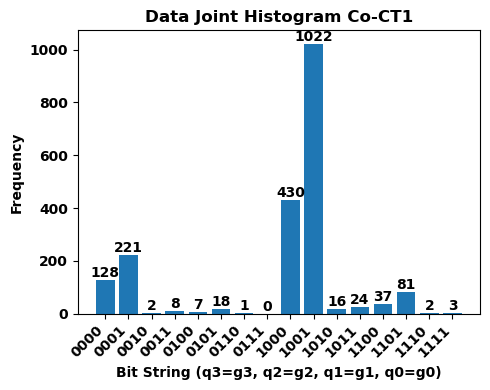

Joint Counts: Counter({'1001': 1022, '1000': 430, '0001': 221, '0000': 128, '1101': 81, '1100': 37, '1011': 24, '0101': 18, '1010': 16, '0011': 8, '0100': 7, '1111': 3, '0010': 2, '1110': 2, '0110': 1})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [6]:
joint_counts_ct1_co, bit_strings_ct1_co = create_joint_histogram(Xct1_binary_co)
#joint_counts_ct1_co, bit_strings_ct1_co = create_percent_joint_histogram(Xct1_binary_co)

num_qubits = Xct1_binary_co.shape[1] 
plot_joint_histogram(joint_counts_ct1_co, num_qubits = num_qubits, features=gl_source, figsize = (5,4), filename = 'joint_counts_co_ct1.svg', title='Data Joint Histogram Co-CT1' )  # Pass num_qubits
#plot_joint_histogram(histogram_data, figsize=(5,4), filename = 'hist_cc_3_4pi.svg', title= r'Histogram $Ry(3\pi/4)$' )

print("Joint Counts:", joint_counts_ct1_co)
print("Bit Strings:", bit_strings_ct1_co)

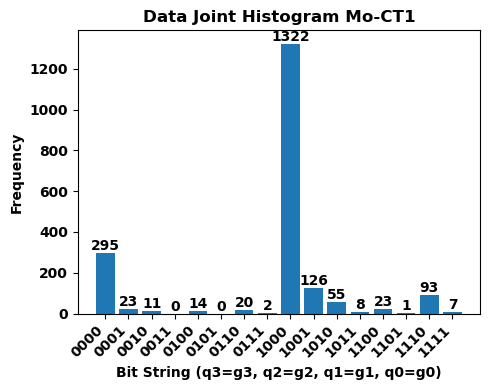

Joint Counts: Counter({'1000': 1322, '0000': 295, '1001': 126, '1110': 93, '1010': 55, '1100': 23, '0001': 23, '0110': 20, '0100': 14, '0010': 11, '1011': 8, '1111': 7, '0111': 2, '1101': 1})
Bit Strings: ['0000', '0001', '0010', '0100', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [7]:
joint_counts_ct1_mo, bit_strings_ct1_mo = create_joint_histogram(Xct1_binary_mo)
#joint_counts_ct1_mo, bit_strings_ct1_mo = create_percent_joint_histogram(Xct1_binary_mo)

num_qubits = Xct1_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_mo, num_qubits = num_qubits, features=gl_source, figsize = (5,4), filename = 'joint_counts_mo_ct1.svg', title='Data Joint Histogram Mo-CT1' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_mo)
print("Bit Strings:", bit_strings_ct1_mo)

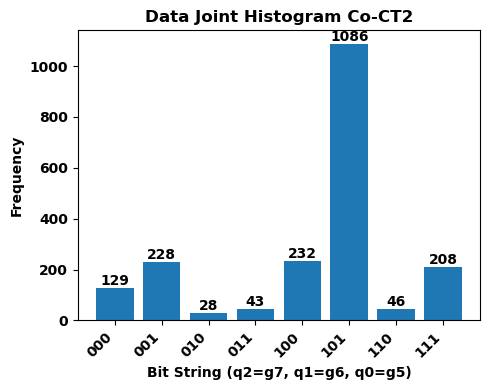

Joint Counts: Counter({'101': 1086, '100': 232, '001': 228, '111': 208, '000': 129, '110': 46, '011': 43, '010': 28})
Bit Strings: ['000', '001', '010', '011', '100', '101', '110', '111']


In [8]:
joint_counts_ct2_co, bit_strings_ct2_co = create_joint_histogram(Xct2_binary_co)
#joint_counts_ct2_co, bit_strings_ct2_co = create_percent_joint_histogram(Xct2_binary_co)

num_qubits2 = Xct2_binary_co.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_co, num_qubits = num_qubits2, features=gl_recv, figsize = (5,4), filename = 'joint_counts_co_ct2.svg', title='Data Joint Histogram Co-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_co)
print("Bit Strings:", bit_strings_ct2_co)

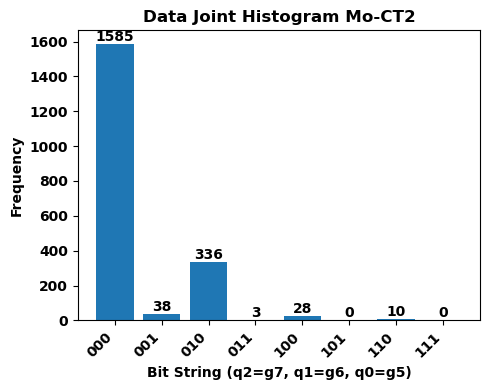

Joint Counts: Counter({'000': 1585, '010': 336, '001': 38, '100': 28, '110': 10, '011': 3})
Bit Strings: ['000', '001', '010', '011', '100', '110']


In [9]:
joint_counts_ct2_mo, bit_strings_ct2_mo = create_joint_histogram(Xct2_binary_mo)
#joint_counts_ct2_mo, bit_strings_ct2_mo = create_percent_joint_histogram(Xct2_binary_mo)

num_qubits2 = Xct2_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_mo, num_qubits = num_qubits2, features=gl_recv, figsize = (5,4), filename = 'joint_counts_mo_ct2.svg', title='Data Joint Histogram Mo-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_mo)
print("Bit Strings:", bit_strings_ct2_mo)

In [10]:
from quantum_functions import vector_normalize_dictionary_values, create_initial_circuit2

import numpy as np
# --- Apply and Print ---
print("--- New Dictionary Definitions ---")
print("State Set CT1 MO:", joint_counts_ct1_mo)
print("State Set CT2 MO:", joint_counts_ct2_mo)
print("Interacted State Set CT1 CO:", joint_counts_ct1_co)
print("Interacted State Set CT2 CO:", joint_counts_ct2_co)

# Apply vector normalization to the new dictionaries
normalized_joint_counts_ct1_mo = vector_normalize_dictionary_values(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = vector_normalize_dictionary_values(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = vector_normalize_dictionary_values(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = vector_normalize_dictionary_values(joint_counts_ct2_co)

print("\n--- Vector Normalized Dictionary Definitions ---")
print("Normalized State Set 5a (Vector Norm):", normalized_joint_counts_ct1_mo)
print("Normalized State Set 6a (Vector Norm):", normalized_joint_counts_ct2_mo)
print("Normalized Interacted State Set 5a (Vector Norm):", normalized_joint_counts_ct1_co)
print("Normalized Interacted State Set 6a (Vector Norm):", normalized_joint_counts_ct2_co)
# 1. Define initial circuits for concatenation
circ1 = create_initial_circuit2(normalized_joint_counts_ct1_mo)
circ2 = create_initial_circuit2(normalized_joint_counts_ct2_mo)

--- New Dictionary Definitions ---
State Set CT1 MO: Counter({'1000': 1322, '0000': 295, '1001': 126, '1110': 93, '1010': 55, '1100': 23, '0001': 23, '0110': 20, '0100': 14, '0010': 11, '1011': 8, '1111': 7, '0111': 2, '1101': 1})
State Set CT2 MO: Counter({'000': 1585, '010': 336, '001': 38, '100': 28, '110': 10, '011': 3})
Interacted State Set CT1 CO: Counter({'1001': 1022, '1000': 430, '0001': 221, '0000': 128, '1101': 81, '1100': 37, '1011': 24, '0101': 18, '1010': 16, '0011': 8, '0100': 7, '1111': 3, '0010': 2, '1110': 2, '0110': 1})
Interacted State Set CT2 CO: Counter({'101': 1086, '100': 232, '001': 228, '111': 208, '000': 129, '110': 46, '011': 43, '010': 28})

--- Vector Normalized Dictionary Definitions ---
Normalized State Set 5a (Vector Norm): {'0000': 0.2160634743698323, '1000': 0.9682573325997231, '1100': 0.01684562681527506, '1110': 0.06811492581828613, '0100': 0.010253859800602212, '1010': 0.040283020645222975, '0010': 0.008056604129044595, '0110': 0.014648371143717445

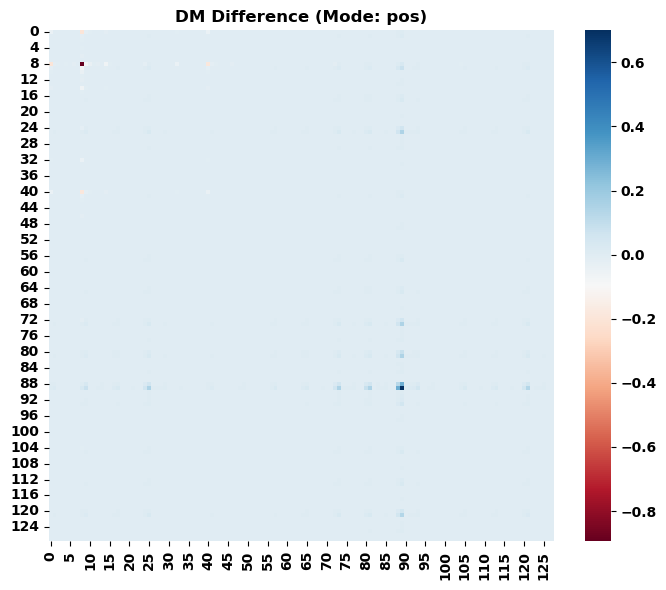


--- CNOT Analysis (pos) ---
Max Signal: 0.6999
Candidates Found: 20 / 42
------------------------------

{'max_element': 0.6999285684867489, 'min_element': -0.8946568728723291, 'abs_average': 0.0007388666548918791, 'relevant_avg': 0.0007345330534979274}


In [11]:
from quantum_functions import find_cnot_candidates_from_state_diff
thresh = 0.1
# --- State and Density Matrix Analysis ---
initial_cnot_config, stats = find_cnot_candidates_from_state_diff(
    normalized_joint_counts_ct1_mo, normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co, normalized_joint_counts_ct2_co,
    threshold = thresh, search_mode="pos", show_plot = True, verbose_print = True
    )

print(stats)


--- Running N-wise Search ---

--- Starting Iterative Pairwise Search ---


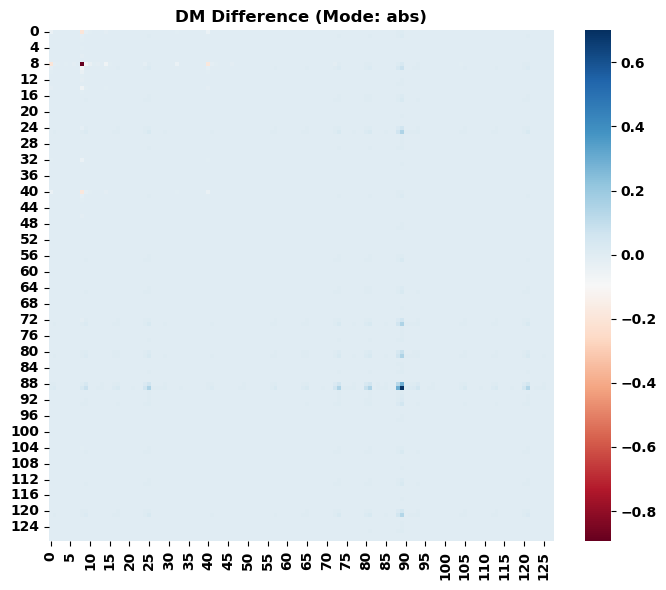


--- CNOT Analysis (abs) ---
Max Signal: 0.6999
Candidates Found: 20 / 42
------------------------------

Number of initial CNOT candidates: 20
Initial KL-divergence: 6.166710

  - Starting Efficiency-Optimized Search -

--- Iteration 1 | Current KL: 6.172299 ---
   - Single Insertion Phase: Added (3, 0) at index 0. New KL: 4.751733
  [Phase 1] Added Single: (3, 0) | New KL: 4.751733
  [Phase 2] Added Pair: ((3, 4), (3, 6)) | New KL: 1.787873

--- Iteration 2 | Current KL: 1.787873 ---
   - Single Insertion Phase: Added (0, 4) at index 3. New KL: 1.395798
  [Phase 1] Added Single: (0, 4) | New KL: 1.395798
  [Phase 2] Added Pair: ((4, 6), (6, 0)) | New KL: 0.458947

--- Iteration 3 | Current KL: 0.458947 ---
  - No improvements in any phase. Search Terminated.

--- Total Search Time: 258.24s ---

--- Pairwise Addition Result ---
Best sequence after addition: [(3, 0), (3, 4), (3, 6), (0, 4), (4, 6), (6, 0)]
KL sum after addition: 0.458947

Total search time: 259.18 seconds.

Multi-Epoch

In [12]:
from quantum_functions import find_best_cnot_sequence_iterative_n_wise, concatenate_circuits_with_separate_measurements, add_cnots_and_measurements_to_circuit

np.random.seed(42) 

print("\n" + "="*40)
print("--- Running N-wise Search ---")
print("="*40)

# Single insertion can be insertion or deletation of CX (something failing with the update criteria)
all_possible_single_cnots, best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_iterative_n_wise(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= thresh,
    nchoose=2,
    kl_tol = 0.05, 
    ratio_kl_tol = 0.6
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running circuit for: CNOT Optimized Circuit ---
Counts for c_measure1: {'1001': 3764, '1000': 962, '0000': 244, '1111': 11, '1011': 5, '1110': 6, '0001': 2, '1010': 3, '1100': 1, '1101': 1, '0010': 1}
Counts for c_measure2: {'101': 3401, '000': 782, '111': 165, '100': 582, '010': 35, '110': 34, '011': 1}


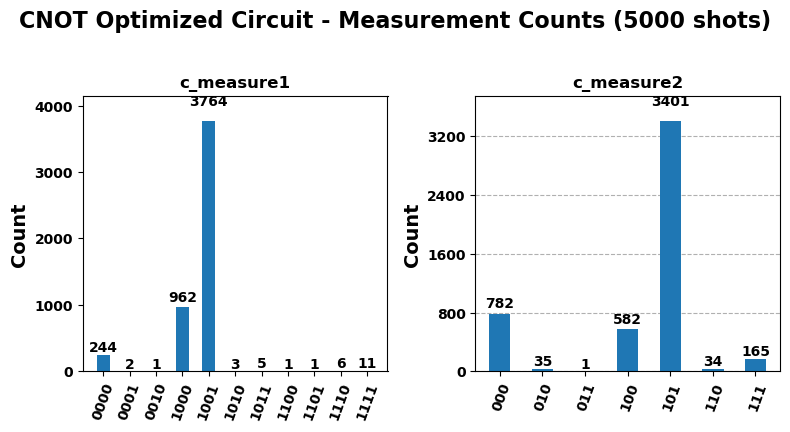

findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


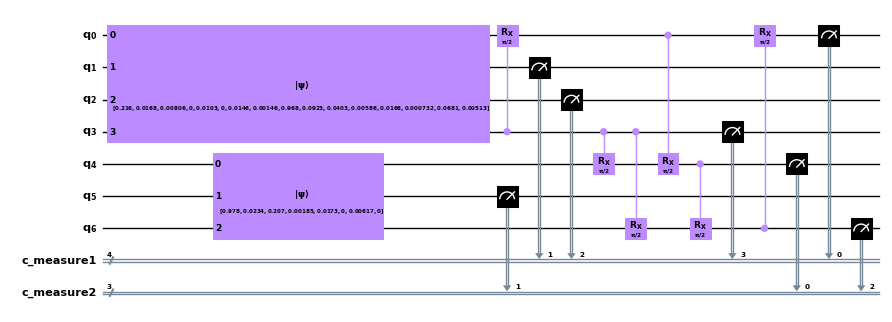

In [13]:
from quantum_functions import plot_measurement_histograms

measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, 
                            title_prefix="CNOT Optimized Circuit", figsize=(8,4.5), 
                            #figure_save_name = "cnot_optimized_circuit_histograms.svg" 
                            )
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5, #0.3
                               filename="cnot_optimized_circuit.svg")

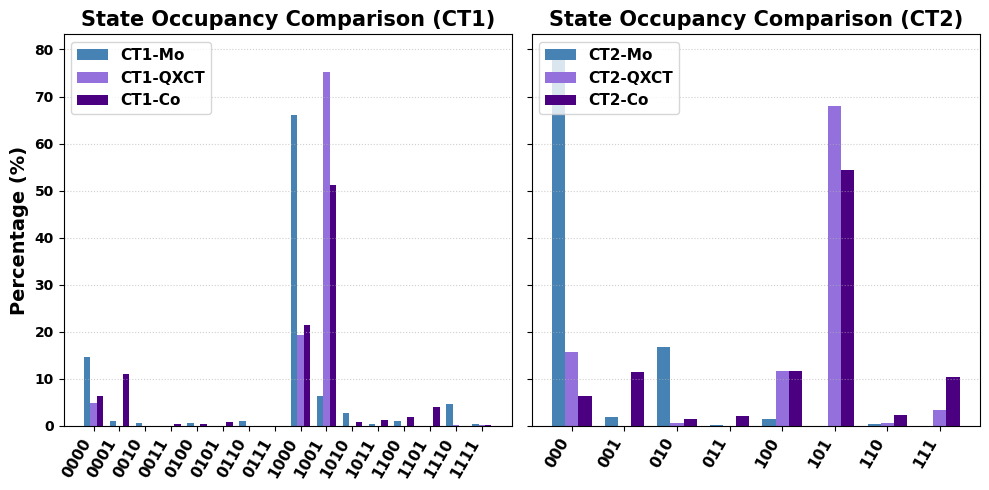

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
#plt.savefig('state_occupancy_comparison.svg')
plt.show()


--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (6 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['2.8552', '1.2764', '1.9756', '1.6921', '1.6425', '0.9684']
CRX Angle Optimization took: 26.82 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['2.8552', '1.2764', '1.9756', '1.6921', '1.6425', '0.9684']
  Minimum Combined KL Divergence with Optimized CRX: 0.156829


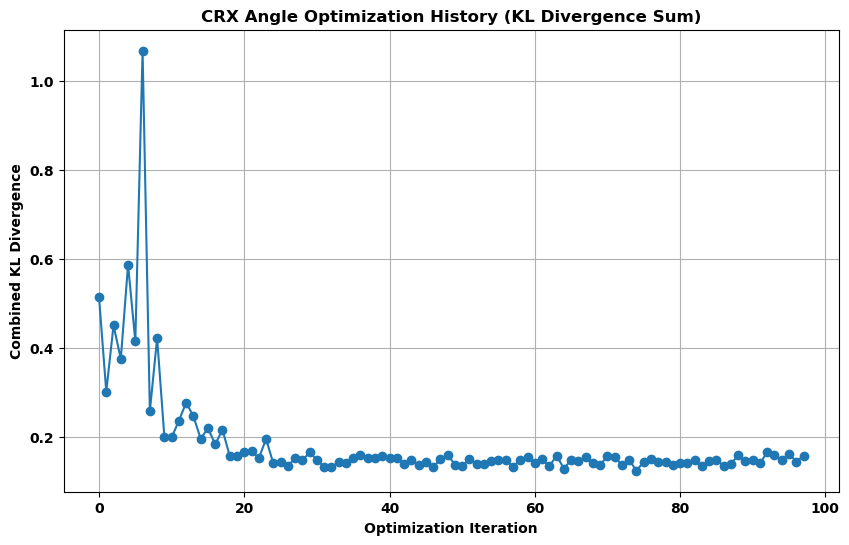


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
c_measure1: 4/»
              »
c_measure2: 3/»
              »
«              ┌────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«         q_0: ┤0                                                                                                                                                   ├»
«              │                                                                                                                                                    │»
«         q_1: ┤1                                                                                                                                    

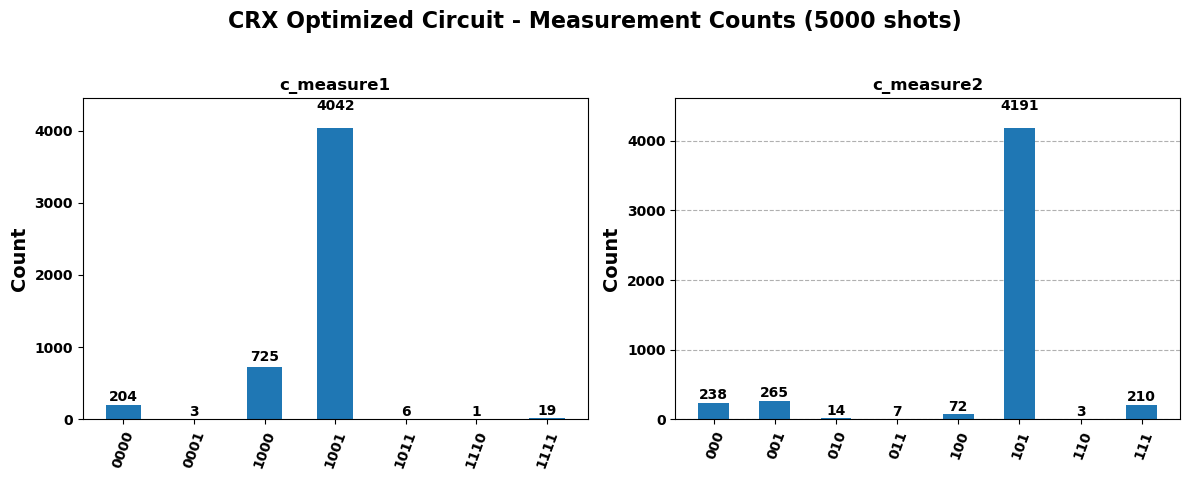

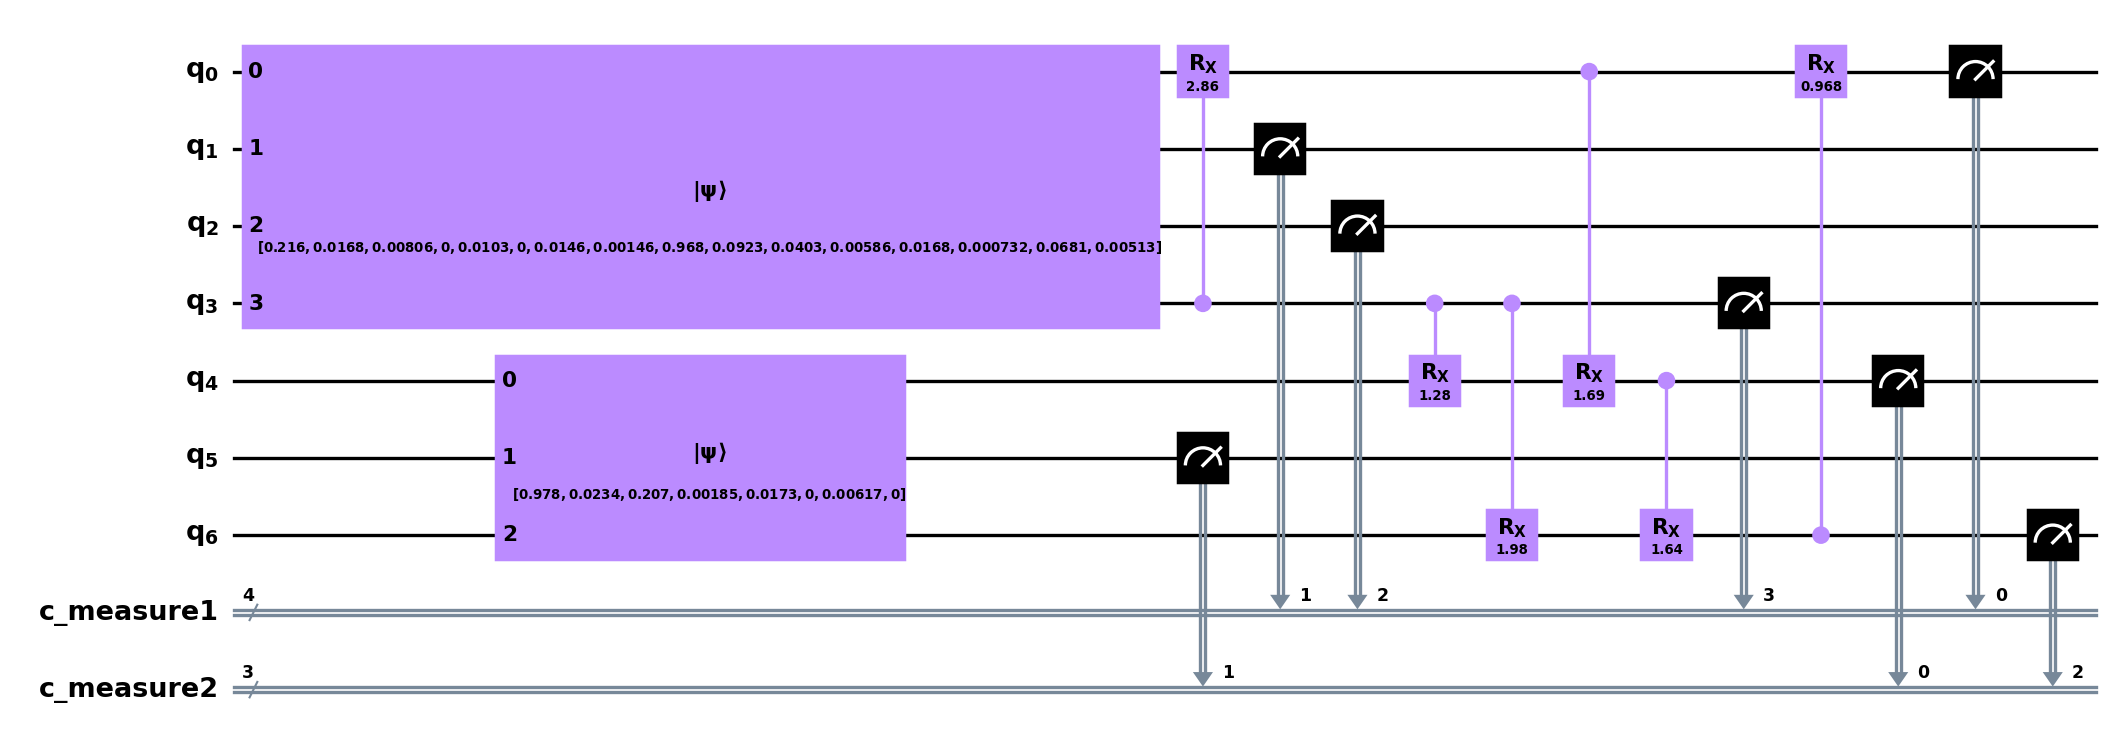

In [15]:
from quantum_functions import optimize_crx_angles, add_crx_gates_and_measurements_to_circuit

# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)

optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    best_cnot_sequence, # Use the CNOT topology found by brute-force
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi*1/2 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_crx_optimized_circuit, nshots=5000, title_prefix="CRX Optimized Circuit")
final_crx_optimized_circuit
final_crx_optimized_circuit.draw(output="mpl", style="clifford", fold=40, scale=1.2)

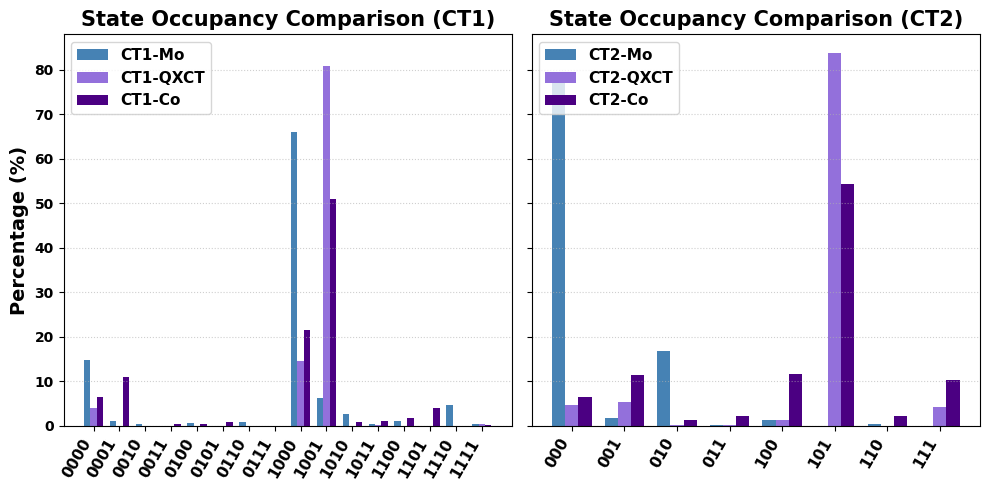

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
#plt.savefig('state_occupancy_comparison.svg')
plt.show()


--- Running Multi-Epoch Refined Search ---

--- Starting Multi-Epoch Refined Search ---

--- Generating CNOT candidates from density matrix difference. ---


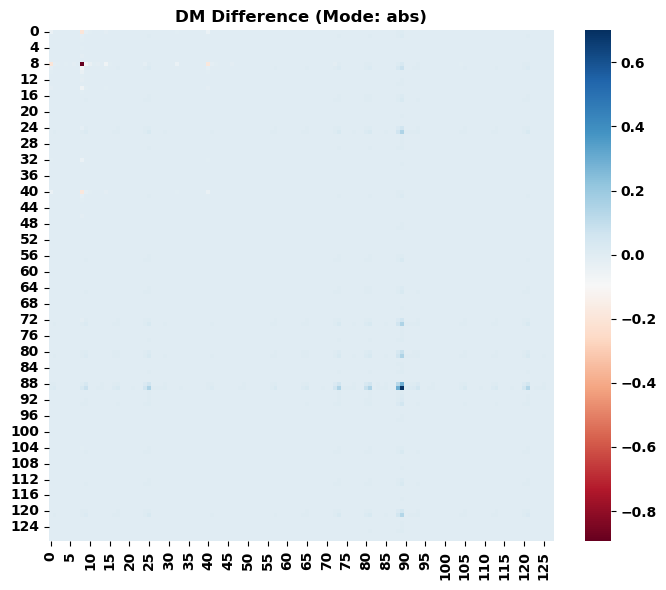


--- CNOT Analysis (abs) ---
Max Signal: 0.6999
Candidates Found: 20 / 42
------------------------------

Initial KL divergence (baseline): 6.162541

--- Starting Epoch 1/20 (Addition) with CNOT: (0, 3) (KL: 6.185827) ---
  Skipping epoch: Single CNOT KL (6.185827) does not improve over baseline (6.162541).

--- Starting Epoch 2/20 (Addition) with CNOT: (5, 0) (KL: 6.061459) ---
    --> Found a better KL on this path: 4.712924 at depth 2 with added CNOT (3, 0)
    --> Found a better KL on this path: 3.478983 at depth 3 with added CNOT (3, 6)
    --> Found a better KL on this path: 1.810823 at depth 4 with added CNOT (3, 4)
    --> Found a better KL on this path: 1.342993 at depth 5 with added CNOT (0, 6)
    --> Found a better KL on this path: 0.757998 at depth 6 with added CNOT (6, 4)
    --> Found a better KL on this path: 0.486397 at depth 7 with added CNOT (4, 0)
    --> Found a better KL on this path: 0.485196 at depth 8 with added CNOT (5, 3)
  Epoch 2 best KL Sum: 0.485196
  -->

In [17]:
from quantum_functions import find_best_cnot_sequence_multi_epoch

np.random.seed(42) 

print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)

n_epochs = 40
min_greedy_depth = 2

best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_multi_epoch(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    n_epochs=n_epochs,
    min_cnot_depth=min_greedy_depth,
    nshots=5000,
    threshold = thresh,
    kl_tol = 0.05,
    ratio_kl_tol = 0.6
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )


    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running circuit for: CNOT Optimized Circuit ---
Counts for c_measure1: {'1001': 3636, '1000': 978, '0000': 275, '0001': 74, '1101': 3, '0110': 2, '1011': 10, '1110': 6, '1111': 16}
Counts for c_measure2: {'001': 543, '101': 3440, '000': 815, '111': 111, '011': 54, '010': 17, '110': 17, '100': 3}


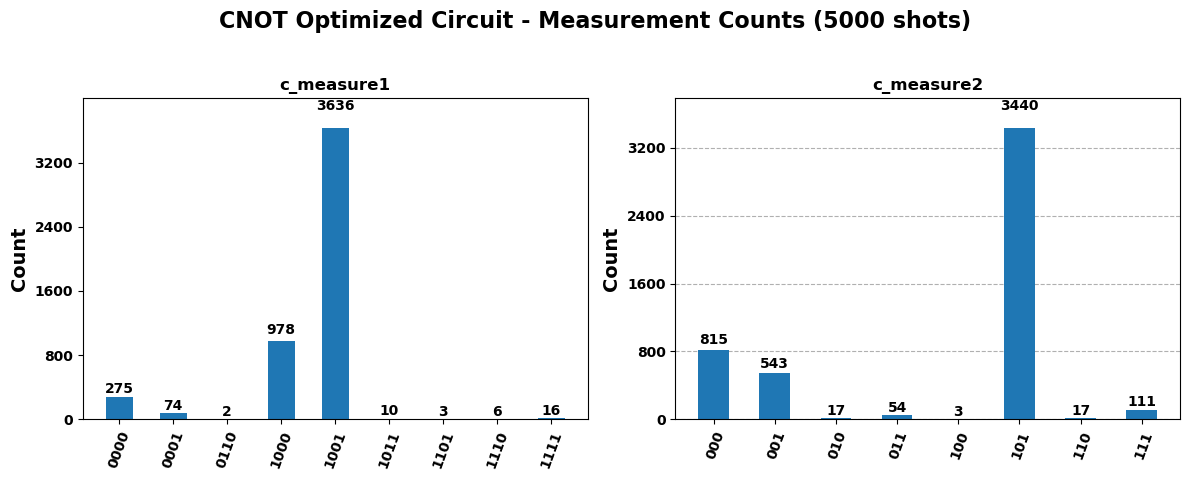

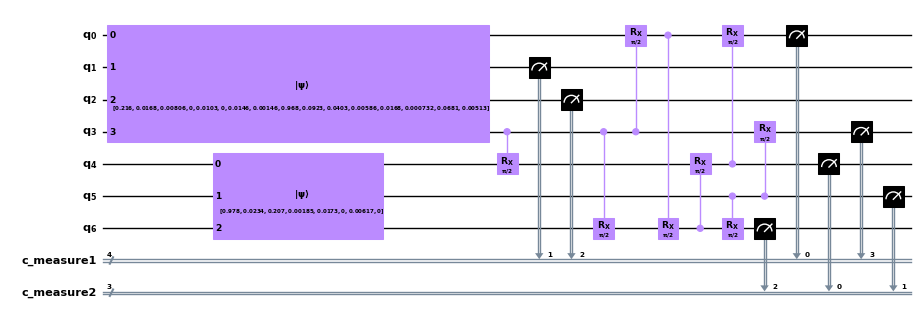

In [18]:
measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, title_prefix="CNOT Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)

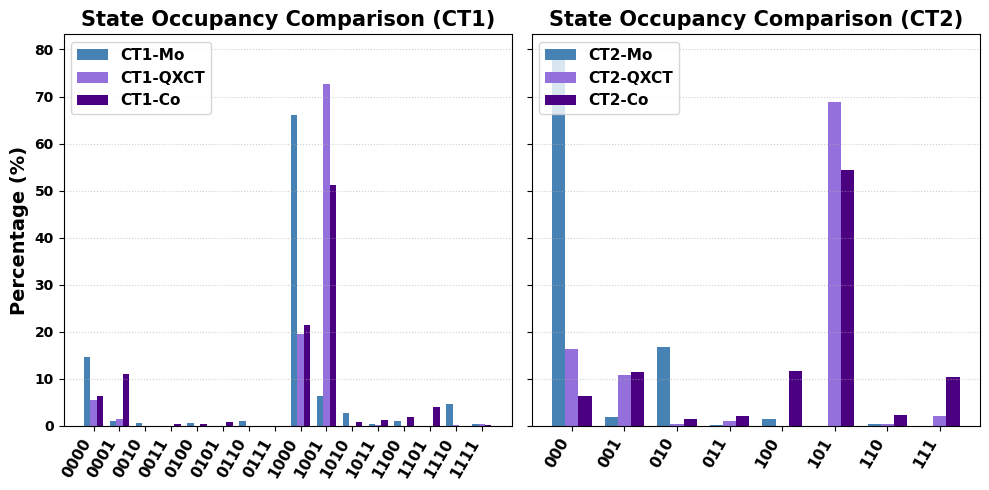

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
#plt.savefig('state_occupancy_comparison.svg')
plt.show()


--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (8 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['1.4596', '2.6816', '1.0400', '0.4516', '1.3462', '1.4202', '1.0792', '1.7305']
CRX Angle Optimization took: 30.41 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['1.4596', '2.6816', '1.0400', '0.4516', '1.3462', '1.4202', '1.0792', '1.7305']
  Minimum Combined KL Divergence with Optimized CRX: 0.132566


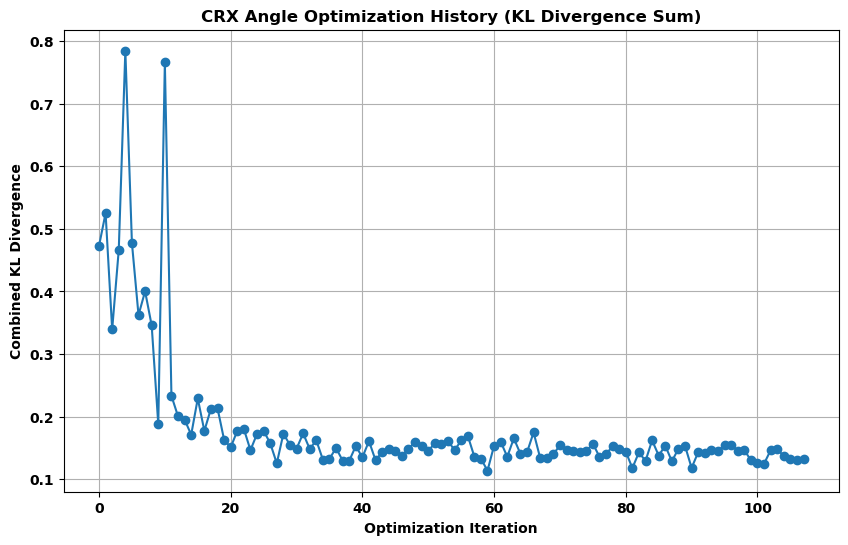


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
c_measure1: 4/»
              »
c_measure2: 3/»
              »
«              ┌────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«         q_0: ┤0                                                                                                                                                   ├»
«              │                                                                                                                                                    │»
«         q_1: ┤1                                                                                                                                    

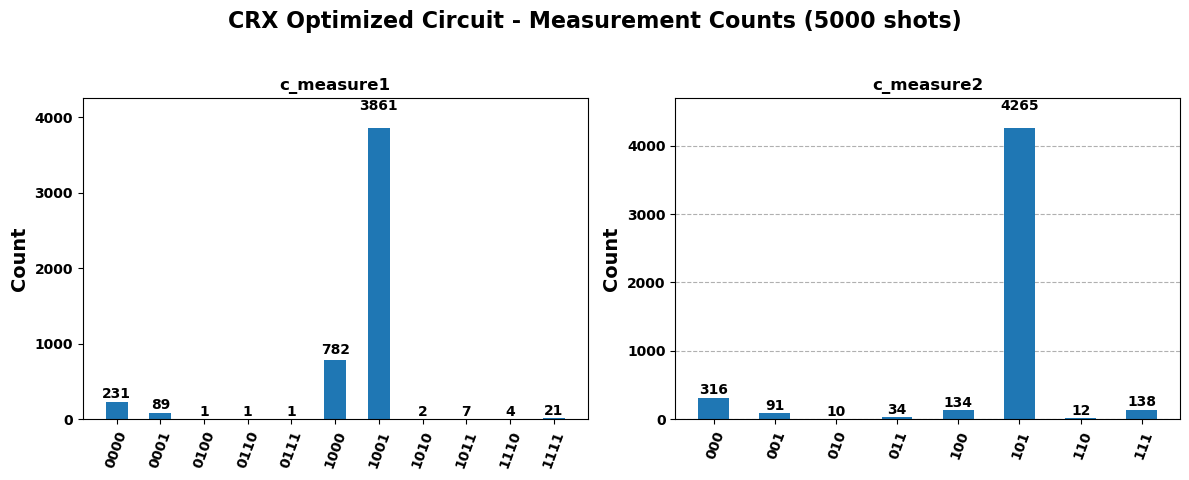

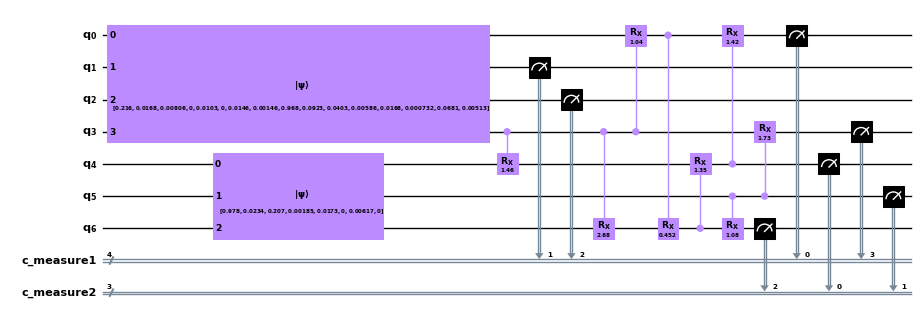

In [20]:
from quantum_functions import optimize_crx_angles, add_crx_gates_and_measurements_to_circuit

# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)

optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    best_cnot_sequence, # Use the CNOT topology found by brute-force
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi*1/2 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_crx_optimized_circuit, nshots=5000, title_prefix="CRX Optimized Circuit")
final_crx_optimized_circuit
final_crx_optimized_circuit.draw(output="mpl", style="clifford", fold=40, scale=0.5)

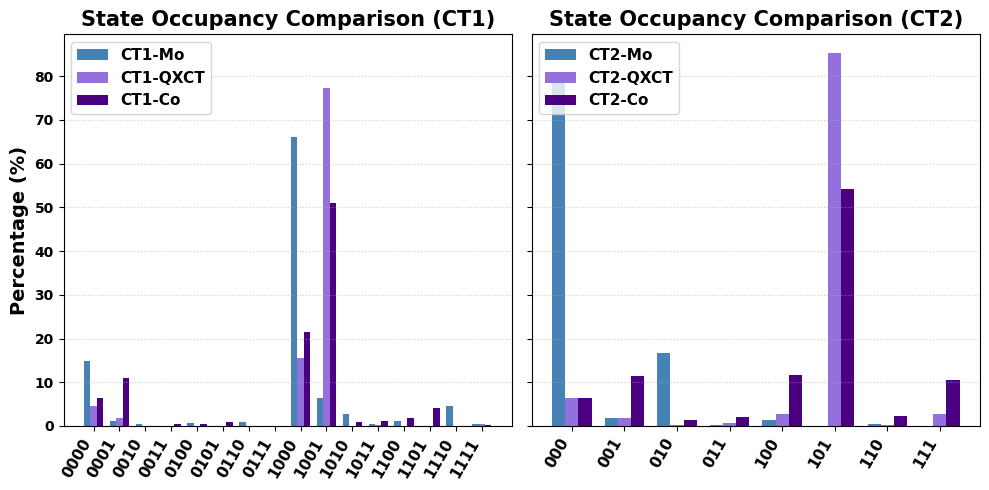

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
#plt.savefig('state_occupancy_comparison.svg')
plt.show()


--- Creating QUBO matrix ---

--- Identifying Potential CNOT Linkers from Density Matrix Difference ---


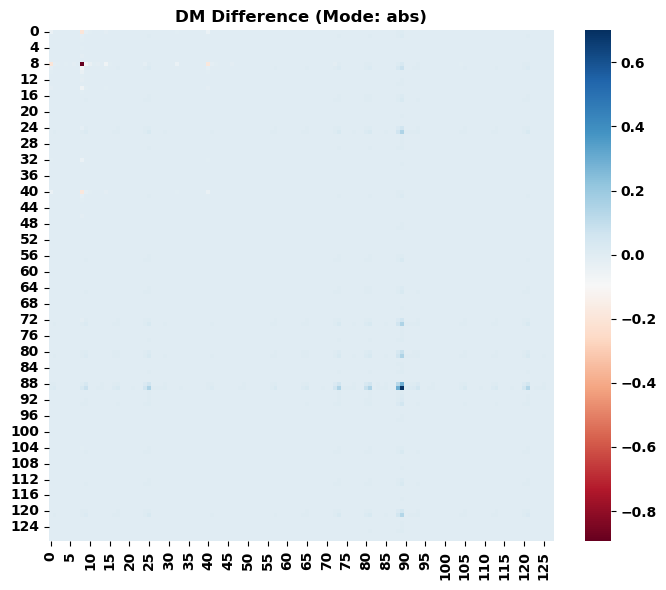


--- CNOT Analysis (abs) ---
Max Signal: 0.6999
Candidates Found: 20 / 42
------------------------------

Initial KL Divergence (no CNOTs): 6.161768

--- Building KL Divergence Matrix (20x20) ---
Calculating KL for single CNOTs (diagonal elements)...
Calculating KL for CNOT pairs (off-diagonal elements)...
Total CNOT pairs tested: 380
--- KL Divergence Matrix Built ---


In [22]:
from quantum_functions import build_kl_divergence_matrix_interaction

np.random.seed(42) 

print("\n" + "="*40)
print("--- Creating QUBO matrix ---")
print("="*40)
    
kl_divergence_matrix, cnot_to_index, initial_cnot_config, initial_kl_sum = build_kl_divergence_matrix_interaction(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= thresh, 
    include_single_cnot_kl=True
)

In [23]:
from quantum_functions import kl_to_qubo_matrix

# Creating Q matrix 
kl_div_mat_qubo = kl_to_qubo_matrix(kl_matrix = kl_divergence_matrix, initial_kl_sum = initial_kl_sum)

In [24]:
from qiskit_optimization import QuadraticProgram
from qiskit.quantum_info import SparsePauliOp
import numpy as np

# Assume kl_div_mat_qubo is your 42x42 NumPy array

num_qubits = kl_div_mat_qubo.shape[0]

# --- 1. Define the Quadratic Program (QUBO) ---
qp = QuadraticProgram(name="CnotOptimization")

for i in range(num_qubits):
    qp.binary_var(name=f'x{i}')

# Set the objective function to minimize the cost defined by the QUBO matrix
# The matrix must be passed as the 'quadratic' term.
qp.minimize(quadratic=kl_div_mat_qubo)

# --- 2. Convert the QUBO to an Ising Hamiltonian ---
# The Ising Converter performs the necessary transformation (x = (1 - Z)/2)
hamiltonian, offset = qp.to_ising()
print(offset)
print(hamiltonian)

-4.899000776182017
SparsePauliOp(['IIIIIIIIIIIIIIIIIIIZ', 'IIIIIIIIIIIIIIIIIIZZ', 'IIIIIIIIIIIIIIIIIIZI', 'IIIIIIIIIIIIIIIIIZIZ', 'IIIIIIIIIIIIIIIIIZII', 'IIIIIIIIIIIIIIIIZIIZ', 'IIIIIIIIIIIIIIIIZIII', 'IIIIIIIIIIIIIIIZIIIZ', 'IIIIIIIIIIIIIIIZIIII', 'IIIIIIIIIIIIIIZIIIIZ', 'IIIIIIIIIIIIIIZIIIII', 'IIIIIIIIIIIIIZIIIIIZ', 'IIIIIIIIIIIIIZIIIIII', 'IIIIIIIIIIIIZIIIIIIZ', 'IIIIIIIIIIIIZIIIIIII', 'IIIIIIIIIIIZIIIIIIIZ', 'IIIIIIIIIIIZIIIIIIII', 'IIIIIIIIIIZIIIIIIIIZ', 'IIIIIIIIIIZIIIIIIIII', 'IIIIIIIIIZIIIIIIIIIZ', 'IIIIIIIIIZIIIIIIIIII', 'IIIIIIIIZIIIIIIIIIIZ', 'IIIIIIIIZIIIIIIIIIII', 'IIIIIIIZIIIIIIIIIIIZ', 'IIIIIIIZIIIIIIIIIIII', 'IIIIIIZIIIIIIIIIIIIZ', 'IIIIIIZIIIIIIIIIIIII', 'IIIIIZIIIIIIIIIIIIIZ', 'IIIIIZIIIIIIIIIIIIII', 'IIIIZIIIIIIIIIIIIIIZ', 'IIIIZIIIIIIIIIIIIIII', 'IIIZIIIIIIIIIIIIIIIZ', 'IIIZIIIIIIIIIIIIIIII', 'IIZIIIIIIIIIIIIIIIIZ', 'IIZIIIIIIIIIIIIIIIII', 'IZIIIIIIIIIIIIIIIIIZ', 'IZIIIIIIIIIIIIIIIIII', 'ZIIIIIIIIIIIIIIIIIIZ', 'ZIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIZZI', 'IIIII

In [25]:
from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_aer import AerSimulator
from qiskit.circuit.library import EfficientSU2
from qiskit.circuit import QuantumCircuit
from qiskit.compiler import transpile
import numpy as np

# --- 1. Configuration (Example values) ---
num_qubits = kl_div_mat_qubo.shape[0]
reps = 1
entanglement = 'circular'  # linear sca circular pairwise reverse_linear full

# --- 2. Ansatz Creation ---
ansatz = EfficientSU2( num_qubits=num_qubits, entanglement=entanglement, reps=reps)

basis_gates = ['u', 'cx'] 
# 2. Transpile the circuit to decompose it into the basis gates.
expanded_ansatz = transpile(
    ansatz, 
    basis_gates = basis_gates, 
    optimization_level = 0  # Set to 0 to minimize changes beyond decomposition
)

# To run on hardware, select the backend with the fewest number of jobs in the queue
backend = AerSimulator()
#backend = service.least_busy(operational=True, simulator=False)
#expanded_ansatz.draw()

C:\Users\ssromerogon\AppData\Local\Temp\ipykernel_44668\2260493373.py:14: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2( num_qubits=num_qubits, entanglement=entanglement, reps=reps)


Starting optimization with method: COBYLA
Iteration 0: Current cost: 0.030765062319560114
Iteration 20: Current cost: -0.002071795814390797
Iteration 40: Current cost: -1.1660529044406447
Iteration 60: Current cost: -1.062702599219228
Iteration 80: Current cost: -1.0870723655862136
Iteration 100: Current cost: -1.6203950304352128
Iteration 200: Current cost: -5.539618350844647

Optimization Result:
 message: Maximum number of function evaluations has been exceeded.
 success: False
  status: 2
     fun: -5.611323883134861
       x: [ 1.072e+00  1.157e+00 ...  1.498e+00  1.332e+00]
    nfev: 200
   maxcv: 0.0

Final Energy: -5.611323883134861

Optimized Full Parameters:
  θ[0]: 1.0719582964751273
  θ[1]: 1.1574545683490771
  θ[2]: 3.2662633994177
  θ[3]: 2.1524780479809493
  θ[4]: 2.2134711549878716
  θ[5]: 1.3392829093897671
  θ[6]: 2.0639928200922903
  θ[7]: 1.4796459456482998
  θ[8]: 1.7561663130075336
  θ[9]: 1.048543382280377
  θ[10]: 1.9029255578696609
  θ[11]: 1.8504311820318229
 

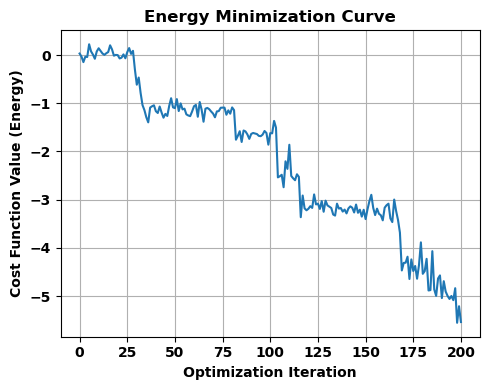

In [26]:
from quantum_functions import vqe_solver
result, optimized_params, cost_values = vqe_solver(
    expanded_ansatz,
    hamiltonian,
    backend,
    optimizer_method="COBYLA", # COBYLA | L-BFGS-B 
    niter= 200
)

# Plot the cost function values
plt.figure(figsize=(5, 4))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
#plt.savefig('vqe_opt_curve_qmat.svg', bbox_inches='tight')
plt.show()    

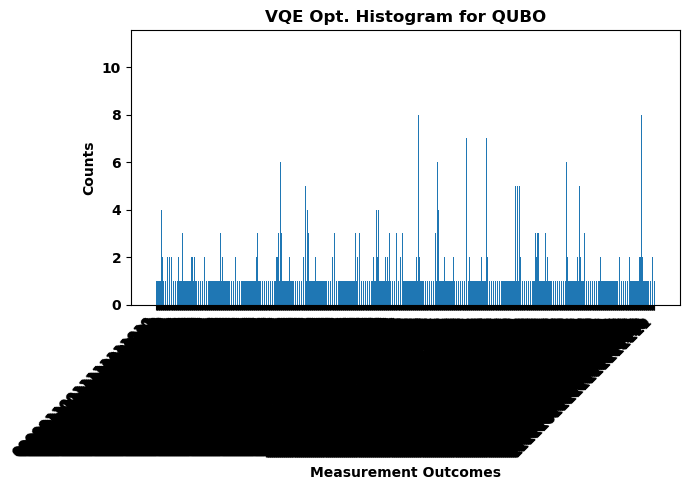

In [27]:
from quantum_functions import evaluate_and_plot_ansatz

counts, bound_circuit = evaluate_and_plot_ansatz(
    ansatz=expanded_ansatz, 
    params=optimized_params, 
    backend=backend,
    shots=1024,
    title="VQE Opt. Histogram for QUBO",
    show_plot=True  # Explicitly show the plot
)
#bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

In [28]:
# ==============================================================================
# --- CALL THE VQE HYBRID SEARCH AND DISPLAY RESULTS ---
# ==============================================================================
from quantum_functions import run_vqe_hybrid_search
# Assume these variables are defined from your previous notebook cells:
# - counts: The dictionary of measurement results from your VQE run.
# - initial_cnot_config: The full list of CNOT candidates used for the VQE QUBO.
# - circ1, circ2: Your two base quantum circuits.
# - normalized_joint_counts_ct1_mo, normalized_joint_counts_ct2_mo: Initial states.
# - normalized_joint_counts_ct1_co, normalized_joint_counts_ct2_co: Target states.
# - thresh: The threshold for density matrix analysis (if used).

# Call the main search function
best_cnot_sequence, min_kl_sum, best_solution_rank = run_vqe_hybrid_search(
    vqe_counts=counts,
    initial_cnot_config=initial_cnot_config,
    circ1=circ1,
    circ2=circ2,
    state_probs_initial1=normalized_joint_counts_ct1_mo,
    state_probs_initial2=normalized_joint_counts_ct2_mo,
    state_vec_probs_target1=normalized_joint_counts_ct1_co,
    state_vec_probs_target2=normalized_joint_counts_ct2_co,
    num_solutions_to_test=3,
    nshots=5000,
    threshold=thresh,
    kl_tol=0.1,
    ratio_kl_tol=0.6,
    max_greedy_depth=30
)

# --- FINAL SUMMARY: Display the Overall Best Solution ---
print("\n" + "="*60)
print("--- OVERALL BEST SOLUTION AFTER HYBRID SEARCH ---")
print("="*60)

if best_solution_rank is not None:
    print(f"The best solution originated from the VQE's result at Rank {best_solution_rank}.")
    print(f"\nFinal optimal CNOT sequence found with {len(best_cnot_sequence)} CNOTs:")
    if best_cnot_sequence:
        for cnot in best_cnot_sequence:
            print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    else:
        print("  (The best solution found was to use no CNOTs)")

    print(f"\nWith a minimum combined KL Divergence of: {min_kl_sum:.6f}")

    # Re-create and draw the final, absolute best circuit
    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("No VQE solution led to a greedy search result that improved upon the initial baseline.")
    print("The best configuration is the baseline circuit with no CNOTs.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))

print("="*60 + "\n")

--- Preparing to test Top 3 VQE solutions in REVERSE order ---

--- Testing VQE Solution (Rank 3/3) ---
This VQE Solution corresponds to a candidate subset of 16 CNOTs:
  q[0] -> q[3]
  q[0] -> q[5]
  q[0] -> q[6]
  q[3] -> q[0]
  q[3] -> q[4]
  q[3] -> q[5]
  q[3] -> q[6]
  q[4] -> q[0]
  q[4] -> q[3]
  q[4] -> q[5]
  q[4] -> q[6]
  q[5] -> q[0]
  q[5] -> q[3]
  q[5] -> q[6]
  q[6] -> q[0]
  q[6] -> q[5]

Setting number of greedy search epochs to 16 (one for each candidate).

--- Starting Multi-Epoch Refined Search ---

--- Using provided CNOT candidate list for the search. ---
Number of candidates to be searched: 16
Initial KL divergence (baseline): 6.185326

--- Starting Epoch 1/16 (Addition) with CNOT: (4, 5) (KL: 6.193102) ---
  Skipping epoch: Single CNOT KL (6.193102) does not improve over baseline (6.185326).

--- Starting Epoch 2/16 (Addition) with CNOT: (3, 0) (KL: 4.761486) ---
    --> Found a better KL on this path: 3.494847 at depth 2 with added CNOT (3, 6)
    --> Found a


--- Running circuit for: VQE + Epoch search Optimized Circuit ---
Counts for c_measure1: {'1000': 1030, '1001': 3708, '0000': 220, '1111': 18, '1110': 8, '1011': 10, '1101': 2, '0110': 1, '0001': 2, '1010': 1}
Counts for c_measure2: {'101': 3407, '000': 782, '010': 45, '001': 580, '111': 165, '011': 20, '100': 1}


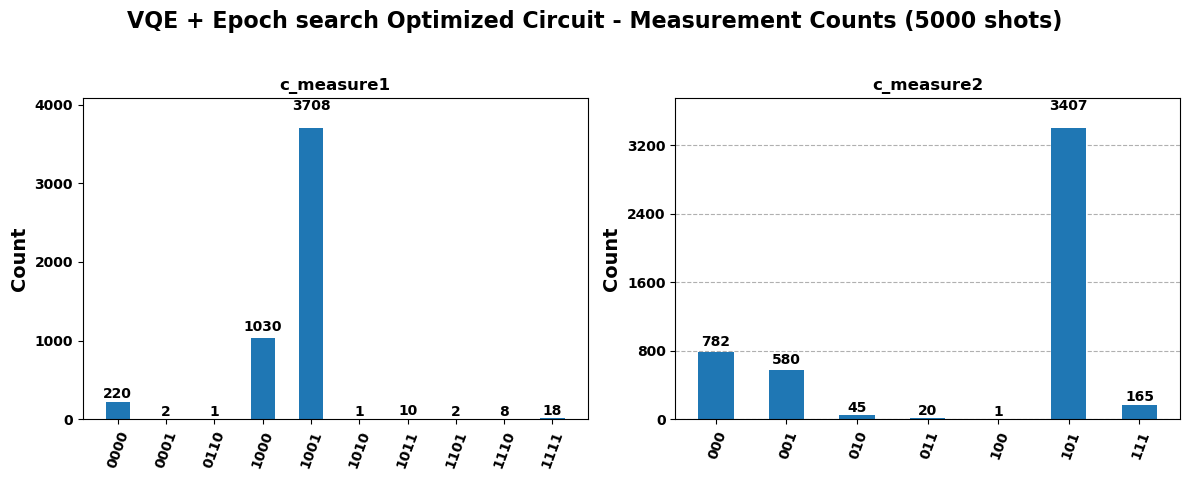

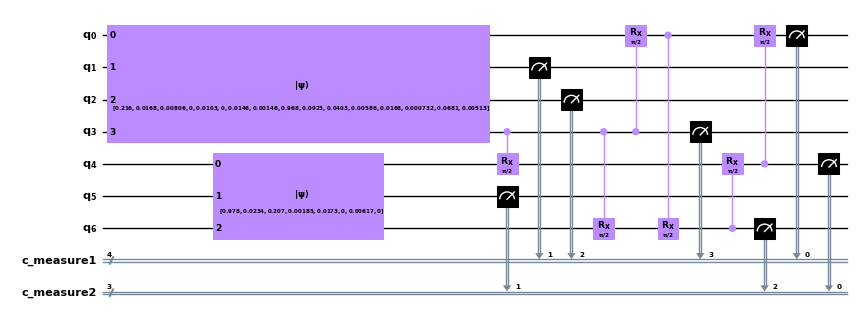

In [29]:
# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_best_circuit_search, nshots=5000, title_prefix="VQE + Epoch search Optimized Circuit")
final_best_circuit_search
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)

In [30]:
# ==============================================================================
# --- STAGE 1: RUN QAOA TO GET CANDIDATE SOLUTIONS ---
# ==============================================================================
# This is your existing QAOA setup code
import numpy as np
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import (
    MinimumEigenOptimizer,
    OptimizationResultStatus,
    RecursiveMinimumEigenOptimizer,
    SolutionSample,
)
from qiskit_optimization.minimum_eigensolvers import QAOA, NumPyMinimumEigensolver
from qiskit_optimization.optimizers import COBYLA
from qiskit_optimization.utils import algorithm_globals
num_qubits = kl_div_mat_qubo.shape[0]
# --- 1. Define the Quadratic Program (QUBO) ---
qp = QuadraticProgram(name="CnotOptimization")
# Add binary variables: one for each CNOT candidate (0 to 41)
for i in range(num_qubits):
    qp.binary_var(name=f'x{i}')
qp.minimize(quadratic=kl_div_mat_qubo)
# kl_vec = np.diag(kl_div_mat_qubo).copy()
# np.fill_diagonal(kl_div_mat_qubo, 0.0)
#qp.minimize(quadratic=kl_div_mat_qubo, linear=kl_vec)
op, offset = qp.to_ising()
print("offset: {}".format(offset))
print(qp.prettyprint())
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2
algorithm_globals.random_seed = 10598
pass_manager = generate_preset_pass_manager(optimization_level=2, backend=AerSimulator())
qaoa_set = QAOA(
    sampler=SamplerV2(seed=123, default_shots=2000),
    optimizer=COBYLA(maxiter=200),
    initial_point=[1, 1],
    pass_manager=pass_manager,
    reps=1
)
meo_set = MinimumEigenOptimizer(qaoa_set)
qaoa_result = meo_set.solve(qp)
print(qaoa_result.prettyprint())


offset: -4.899000776182017
Problem name: CnotOptimization

Minimize
  0.020728556011025745*x0^2 - 0.04533579150158751*x0*x1
  - 0.009657010535631727*x0*x10 - 0.016216912159371155*x0*x11
  - 0.014252300632558779*x0*x12 - 0.010313615192685255*x0*x13
  - 0.014918987635281766*x0*x14 - 0.023351362099588435*x0*x15
  - 0.04301513294999726*x0*x16 - 0.01679188989932534*x0*x17
  - 0.020932191067854156*x0*x18 - 0.020561839465081277*x0*x19
  - 0.021410116647937016*x0*x2 - 0.03849222001657626*x0*x3
  - 0.06247770225202931*x0*x4 - 0.021073439491849477*x0*x5
  + 0.004063058565873412*x0*x6 - 0.02753495652686233*x0*x7
  - 0.04459048851109504*x0*x8 - 0.045992284089220625*x0*x9
  - 0.01215164679459324*x1^2 - 0.012251262857168932*x1*x10
  - 0.04629654167350594*x1*x11 - 0.011828223014205719*x1*x12
  - 0.018925423253007168*x1*x13 - 0.027789592114443096*x1*x14
  - 0.047776219792791785*x1*x15 - 0.032476425363974215*x1*x16
  - 0.01706484610388248*x1*x17 - 0.037556715818654496*x1*x18
  - 0.026328965297553353*x1

In [31]:
# CORRECTED HELPER FUNCTION
from qiskit_optimization.algorithms import SolutionSample 
from typing import List, Dict

def convert_qaoa_samples_to_counts(
    samples: List[SolutionSample], 
    total_shots_equivalent: int = 10000
) -> Dict[str, int]:
    """
    Converts a list of QAOA SolutionSample objects into a VQE-style counts dictionary.

    This is necessary to use the QAOA results with functions designed for VQE/Sampler output.
    It preserves the relative probabilities of the solutions by converting them to integer counts.

    Args:
        samples (List[SolutionSample]): The list of samples from a Qiskit Optimization result.
        total_shots_equivalent (int): A scaling factor to convert probabilities into
                                      integer counts. The exact value doesn't matter as
                                      long as it preserves the order.

    Returns:
        Dict[str, int]: A dictionary where keys are big-endian bitstrings and values are
                        the corresponding "counts", compatible with the hybrid search function.
    """
    qaoa_counts = {}
    for s in samples:
        # QAOA sample.x is an array like [1., 0., 1.]. Convert to a string '101'.
        # We reverse it to create a big-endian string '101' -> ...x2x1x0, which is
        # a common Qiskit convention and consistent with our VQE helpers.
        bitstring = "".join(str(int(v)) for v in reversed(s.x))
        
        # Convert the solution's probability to an integer count
        count = int(s.probability * total_shots_equivalent)
        
        # Only add solutions with a non-zero chance
        if count > 0:
            qaoa_counts[bitstring] = count
            
    return qaoa_counts

In [32]:
# ==============================================================================
# --- STAGE 2: CONVERT QAOA RESULTS AND RUN HYBRID SEARCH ---
# ==============================================================================

# 1. Convert the QAOA samples list into a VQE-style counts dictionary
qaoa_counts = convert_qaoa_samples_to_counts(qaoa_result.samples)
print(f"\nConverted QAOA results into a counts dictionary with {len(qaoa_counts)} entries.")

# 2. Call the main hybrid search function, using the QAOA counts as input
best_cnot_sequence, min_kl_sum, best_solution_rank = run_vqe_hybrid_search(
    vqe_counts=qaoa_counts,  # <-- Using the converted QAOA results here!
    initial_cnot_config=initial_cnot_config,
    circ1=circ1,
    circ2=circ2,
    state_probs_initial1=normalized_joint_counts_ct1_mo,
    state_probs_initial2=normalized_joint_counts_ct2_mo,
    state_vec_probs_target1=normalized_joint_counts_ct1_co,
    state_vec_probs_target2=normalized_joint_counts_ct2_co,
    num_solutions_to_test=3,  # We will test the top 3 solutions from QAOA
    nshots=5000,
    threshold=thresh,
    kl_tol=0.1,
    ratio_kl_tol=0.6,
    max_greedy_depth=30,
    min_cnot_depth=1 # You can adjust this as needed
)

# ==============================================================================
# --- STAGE 3: DISPLAY THE FINAL, OVERALL BEST SOLUTION ---
# ==============================================================================
print("\n" + "="*60)
print("--- OVERALL BEST SOLUTION AFTER QAOA + HYBRID SEARCH ---")
print("="*60)

if best_solution_rank is not None:
    print(f"The best solution originated from the QAOA's result at Rank {best_solution_rank}.")
    print(f"\nFinal optimal CNOT sequence found with {len(best_cnot_sequence)} CNOTs:")
    if best_cnot_sequence:
        for cnot in best_cnot_sequence:
            print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    else:
        print("  (The best solution found was to use no CNOTs)")

    print(f"\nWith a minimum combined KL Divergence of: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("No QAOA solution led to a greedy search result that improved upon the initial baseline.")
    print("The best configuration is the baseline circuit with no CNOTs.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))

print("="*60 + "\n")


Converted QAOA results into a counts dictionary with 1910 entries.
--- Preparing to test Top 3 VQE solutions in REVERSE order ---

--- Testing VQE Solution (Rank 3/3) ---
This VQE Solution corresponds to a candidate subset of 20 CNOTs:
  q[0] -> q[3]
  q[0] -> q[4]
  q[0] -> q[5]
  q[0] -> q[6]
  q[3] -> q[0]
  q[3] -> q[4]
  q[3] -> q[5]
  q[3] -> q[6]
  q[4] -> q[0]
  q[4] -> q[3]
  q[4] -> q[5]
  q[4] -> q[6]
  q[5] -> q[0]
  q[5] -> q[3]
  q[5] -> q[4]
  q[5] -> q[6]
  q[6] -> q[0]
  q[6] -> q[3]
  q[6] -> q[4]
  q[6] -> q[5]

Setting number of greedy search epochs to 20 (one for each candidate).

--- Starting Multi-Epoch Refined Search ---

--- Using provided CNOT candidate list for the search. ---
Number of candidates to be searched: 20
Initial KL divergence (baseline): 6.173283

--- Starting Epoch 1/20 (Addition) with CNOT: (4, 6) (KL: 6.178523) ---
  Skipping epoch: Single CNOT KL (6.178523) does not improve over baseline (6.173283).

--- Starting Epoch 2/20 (Addition) with CN


--- Running circuit for: VQE + Epoch search Optimized Circuit ---
Counts for c_measure1: {'0000': 266, '1001': 3642, '1000': 1054, '1111': 18, '1110': 5, '1011': 9, '0001': 2, '0110': 2, '1010': 1, '0100': 1}
Counts for c_measure2: {'000': 872, '101': 3377, '011': 29, '001': 538, '111': 148, '010': 31, '100': 5}


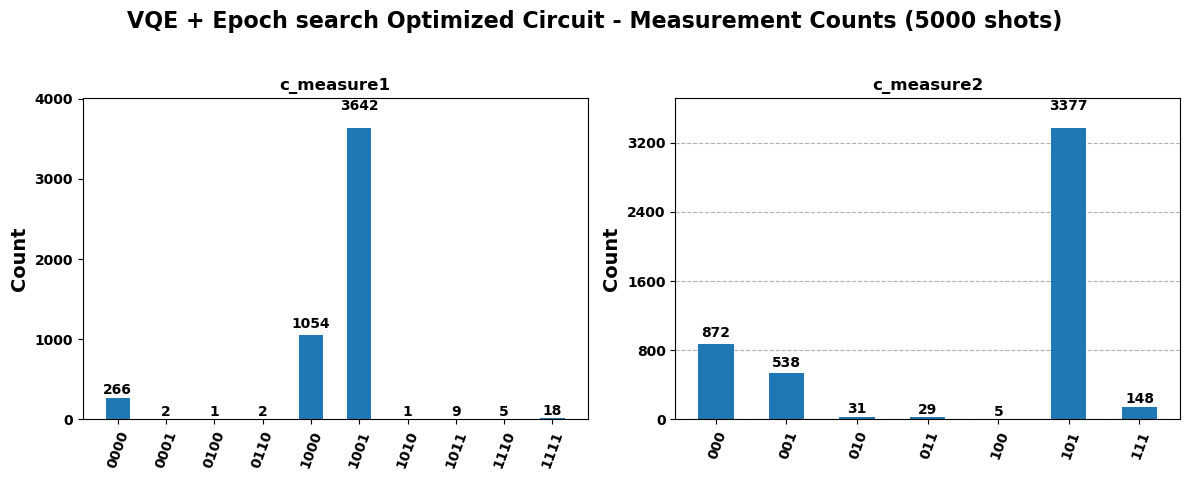

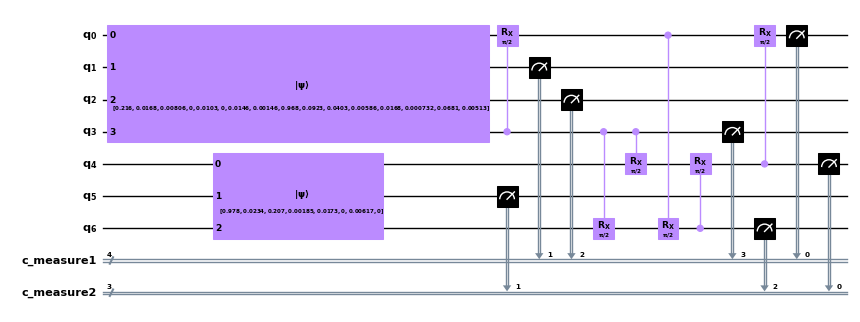

In [33]:
# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_best_circuit_search, nshots=5000, title_prefix="VQE + Epoch search Optimized Circuit")
final_best_circuit_search
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)